# Notebook 09 — Feature Engineering (Kau-Dynamik)

**Motivation:** Die bisherigen ~36 Features sind überwiegend *statistische Aggregate*
(mean / std / max pro Achse + ein kleiner Spektrum-Block). Sie beschreiben **wie stark**
und **wo** das Handy bewegt wird — aber kaum **wie** gekaut wird.

Dieses Notebook fügt **Dynamik-Features** hinzu, die physikalisch zu den Klassen passen:

| Klasse | Charakteristik | Neues Feature |
|--|--|--|
| **Apfel** | harte, impulsive Bisse | Kurtosis, Crest-Factor, Hochfrequenz-Power |
| **Kaugummi** | gleichmäßiges Dauer-Kauen | Spektrale Entropie, Autokorrelations-Peak, `inter_chew_cv` |
| **Skyr** | weich, wenig Kauen | niedrige Kau-Power, `chews_per_sec` |

**Zentrale Frage:** Verbessern die neuen Features die **Session-zu-Session-Generalisierung**
(LOSO, aus NB07), nicht nur die (eh schon hohe) Within-Session-Accuracy (LOO)?

Deshalb wird **jede** Konfiguration mit **beiden** Schemata ausgewertet:
- **LOO** (Leave-One-Out per Fenster) → optimistisch, wie NB04/05
- **LOSO** (Leave-One-Session-Out) → ehrlich, wie NB07

Verglichen werden drei Feature-Sets: **BASE** (36) · **PLUS** (Base + neu) · **DYN** (nur neu).

---
## 1. Setup

In [1]:
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, find_peaks
from scipy.stats import kurtosis, skew

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut, LeaveOneGroupOut
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

CLASSES_RAW  = ['Apfel', 'Kaugummi', 'Skyr', 'Still', 'Essen']
CLASSES_FINE = ['Apfel', 'Kaugummi', 'Skyr', 'Essen']
TO_COARSE    = {'Apfel': 'Essen', 'Kaugummi': 'Essen', 'Skyr': 'Essen',
                'Still': 'Still', 'Essen': 'Essen'}
COLORS = {'Apfel': '#e15759', 'Kaugummi': '#4e79a7', 'Skyr': '#f28e2b',
          'Still': '#59a14f', 'Essen': '#b07aa1'}

FS            = 50.0
TRIM_SECS     = 2
WINDOW_SECS   = 25.0   # wie NB05/NB07 (bestes LOO-Referenzsetting)
STEP_SECS     = 25.0   # kein Overlap -> sauberes LOSO
MIN_TAIL_SECS = 20.0
K_ME          = 5

# Scaler + Modell als Pipeline (korrekte Skalierung pro Fold)
def make_pipeline(clf, scale=True):
    return Pipeline([('sc', StandardScaler()), ('clf', clf)]) if scale else clf

# MLP braucht le=True (LabelEncoder) wegen np.isnan-Bug bei String-Labels
# (Python 3.14 / sklearn 1.8 ruft intern np.isnan auf String-Arrays auf)
MODELS = {
    'SVM': dict(clf=lambda: SVC(kernel='rbf', C=10, class_weight='balanced',
                                random_state=42), scale=True, le=False),
    'MLP': dict(clf=lambda: MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                          solver='adam', max_iter=500,
                                          learning_rate_init=0.001, random_state=42),
                scale=True, le=True),
    'RF':  dict(clf=lambda: RandomForestClassifier(n_estimators=200,
                                                   class_weight='balanced',
                                                   random_state=42), scale=False, le=False),
}
MODEL_COLORS = {'SVM': '#e15759', 'MLP': '#59a14f', 'RF': '#4e79a7'}
SET_COLORS   = {'BASE': '#9c9c9c', 'PLUS': '#4e79a7', 'DYN': '#e15759'}

---
## 2. Daten pro Session laden

Wie NB07: jede Aufnahme bleibt eine eigene *Session* (Gruppe), damit LOSO möglich ist.

In [2]:
DATA_DIR = Path('../data/raw')
_SKIP    = {'Metadata.csv', 'Annotation.csv'}

def preprocess(df):
    df = df.copy()
    t  = df['seconds_elapsed']
    df = df[(t >= t.iloc[0] + TRIM_SECS) & (t <= t.iloc[-1] - TRIM_SECS)].reset_index(drop=True)
    df['lin_x'] = df['accelerationX']
    df['lin_y'] = df['accelerationY']
    df['lin_z'] = df['accelerationZ']
    df['magnitude'] = np.sqrt(df['lin_x']**2 + df['lin_y']**2 + df['lin_z']**2)
    return df

sessions_per_class = {cls: [] for cls in CLASSES_RAW}
for zf in sorted(DATA_DIR.glob('*.zip')):
    for cls in CLASSES_RAW:
        if zf.name.startswith(cls + '_'):
            with zipfile.ZipFile(zf) as z:
                csv_name = next(f for f in z.namelist() if f.endswith('.csv') and f not in _SKIP)
                with z.open(csv_name) as f:
                    sessions_per_class[cls].append(preprocess(pd.read_csv(f)))
            break

print('Sitzungen pro Klasse:')
for cls in CLASSES_RAW:
    durs = [d['seconds_elapsed'].iloc[-1] - d['seconds_elapsed'].iloc[0]
            for d in sessions_per_class[cls]]
    print(f'  {cls:10s}: {len(sessions_per_class[cls]):2d} Sitzungen ({sum(durs):.0f}s)')

Sitzungen pro Klasse:
  Apfel     : 17 Sitzungen (1172s)
  Kaugummi  : 19 Sitzungen (1423s)
  Skyr      : 21 Sitzungen (2582s)
  Still     : 16 Sitzungen (2262s)
  Essen     :  4 Sitzungen (2043s)


---
## 3. Feature-Extraktion: BASE + NEU

`extract_features_base` ist **identisch** zu NB05/08 (36 Features) — so ist der Vergleich fair.
`extract_new_features` ergänzt die Kau-Dynamik. Alle neuen Features sind gegen Randfälle
(leere Arrays, Division durch 0) abgesichert.

In [3]:
def movement_mask(df):
    thr = max(0.02, K_ME * df['magnitude'].median())
    return df['magnitude'].rolling(50, center=True, min_periods=1).max() <= thr

def sliding_windows(df):
    t = df['seconds_elapsed'].values
    t_start, t_end = t[0], t[-1]
    out = []
    while t_start + MIN_TAIL_SECS <= t_end:
        w = df[(t >= t_start) & (t < t_start + WINDOW_SECS)].reset_index(drop=True)
        if len(w) > 1 and (w['seconds_elapsed'].iloc[-1] - w['seconds_elapsed'].iloc[0]) >= MIN_TAIL_SECS:
            out.append(w)
        t_start += STEP_SECS
    return out

# ── BASE: identisch zu NB05/08 ────────────────────────────────────────────────
def extract_features_base(df):
    feats = {}
    for col in ['lin_x', 'lin_y', 'lin_z', 'magnitude']:
        feats[f'{col}_mean'] = df[col].mean()
        feats[f'{col}_std']  = df[col].std()
        feats[f'{col}_max']  = df[col].abs().max()
    feats['stillness_ratio'] = (df['magnitude'] < 0.02).mean()
    feats['movement_events'] = int((df['magnitude'] > df['magnitude'].quantile(0.75)).sum())
    for col in ['rotationRateX', 'rotationRateY', 'rotationRateZ']:
        feats[f'{col}_mean'] = df[col].mean()
        feats[f'{col}_std']  = df[col].std()
        feats[f'{col}_max']  = df[col].abs().max()
    for col in ['pitch', 'roll', 'yaw']:
        feats[f'{col}_mean']  = df[col].mean()
        feats[f'{col}_std']   = df[col].std()
        feats[f'{col}_range'] = df[col].max() - df[col].min()
    nperseg = min(256, len(df) // 2)
    freqs, psd = welch(df['magnitude'].values, fs=FS, nperseg=nperseg)
    chew = (freqs >= 0.5) & (freqs <= 4.0)
    cf, cp = freqs[chew], psd[chew]
    feats['total_power']        = float(psd.sum())
    feats['chew_band_power']    = float(cp.sum())
    feats['rhythmicity']        = feats['chew_band_power'] / feats['total_power'] if feats['total_power'] > 0 else 0.0
    feats['dominant_chew_freq'] = float(cf[np.argmax(cp)]) if len(cp) > 0 else 0.0
    return feats

# ── NEU: Kau-Dynamik ──────────────────────────────────────────────────────────
NEW_FEATURES = ['mag_kurtosis', 'mag_skew', 'crest_factor', 'jerk_mean', 'jerk_std',
                'spectral_entropy', 'spectral_centroid', 'spectral_bandwidth',
                'band_power_slow', 'band_power_mid', 'band_power_fast', 'high_freq_power',
                'ac_peak_height', 'chew_freq_ac', 'chews_per_sec', 'inter_chew_cv']

def extract_new_features(df):
    f   = {k: 0.0 for k in NEW_FEATURES}
    mag = df['magnitude'].values
    t   = df['seconds_elapsed'].values
    dur = (t[-1] - t[0]) if len(t) > 1 else 0.0

    # Impulsivität (-> Apfel: spiky; Kaugummi: glatt)
    rms = np.sqrt(np.mean(mag**2)) if len(mag) else 0.0
    if len(mag) > 3: f['mag_kurtosis'] = float(kurtosis(mag))
    if len(mag) > 2: f['mag_skew']     = float(skew(mag))
    if rms > 1e-9:   f['crest_factor'] = float(np.max(np.abs(mag)) / rms)

    # Jerk = Ableitung der Beschleunigung (Textur-Übergänge)
    if len(mag) > 2:
        jerk = np.diff(mag) * FS
        f['jerk_mean'] = float(np.mean(np.abs(jerk)))
        f['jerk_std']  = float(np.std(jerk))

    # Spektrale Form
    nperseg = min(256, len(mag) // 2)
    if nperseg >= 2:
        freqs, psd = welch(mag, fs=FS, nperseg=nperseg)
        tot = psd.sum()
        if tot > 0:
            p  = psd / tot
            pp = p[p > 0]
            f['spectral_entropy']   = float(-np.sum(pp * np.log2(pp)) / np.log2(len(p)))
            f['spectral_centroid']  = float(np.sum(freqs * p))
            f['spectral_bandwidth'] = float(np.sqrt(np.sum((freqs - f['spectral_centroid'])**2 * p)))
            band = lambda lo, hi: float(psd[(freqs >= lo) & (freqs < hi)].sum() / tot)
            f['band_power_slow'] = band(0.5, 1.5)   # langsames Kauen
            f['band_power_mid']  = band(1.5, 2.5)
            f['band_power_fast'] = band(2.5, 4.0)   # schnelles Kauen
            f['high_freq_power'] = band(4.0, 15.0)  # Knusper-Energie (-> Apfel)

    # Rhythmus via Autokorrelation (-> Kaugummi sehr regelmäßig)
    sig = mag - mag.mean() if len(mag) else mag
    if len(sig) > int(FS):
        ac = np.correlate(sig, sig, mode='full')[len(sig) - 1:]
        ac = ac / (ac[0] + 1e-12)
        lo, hi = int(FS / 4.0), min(int(FS / 0.5), len(ac) - 1)   # 0.5–4 Hz
        if hi > lo:
            peak = np.argmax(ac[lo:hi]) + lo
            f['ac_peak_height'] = float(ac[peak])   # Höhe = Regelmäßigkeit
            f['chew_freq_ac']   = float(FS / peak)

    # Kau-Peaks zählen
    if len(mag) > 5 and mag.std() > 0:
        peaks, _ = find_peaks(mag, distance=max(1, int(FS * 0.2)), prominence=mag.std())
        if dur > 0: f['chews_per_sec'] = float(len(peaks) / dur)
        if len(peaks) > 1:
            iv = np.diff(t[peaks])
            if iv.mean() > 0: f['inter_chew_cv'] = float(iv.std() / iv.mean())
    return f

print(f'{len(NEW_FEATURES)} neue Features definiert:')
print('  ' + ', '.join(NEW_FEATURES))

16 neue Features definiert:
  mag_kurtosis, mag_skew, crest_factor, jerk_mean, jerk_std, spectral_entropy, spectral_centroid, spectral_bandwidth, band_power_slow, band_power_mid, band_power_fast, high_freq_power, ac_peak_height, chew_freq_ac, chews_per_sec, inter_chew_cv


---
## 4. Datensatz bauen (Fenster → Features → Session-IDs)

In [4]:
rows_base, rows_new, y_list, grps = [], [], [], []
session_counter = 0
for cls in CLASSES_RAW:
    for df in sessions_per_class[cls]:
        for w in sliding_windows(df):
            clean = w[movement_mask(w)].reset_index(drop=True)
            if len(clean) > 50:
                rows_base.append(extract_features_base(clean))
                rows_new.append(extract_new_features(clean))
                y_list.append(cls)
                grps.append(session_counter)
        session_counter += 1

X_base = pd.DataFrame(rows_base).reset_index(drop=True)
X_new  = pd.DataFrame(rows_new)[NEW_FEATURES].reset_index(drop=True)
X_plus = pd.concat([X_base, X_new], axis=1)
y_raw  = np.array(y_list)
groups = np.array(grps)
y_coarse = np.array([TO_COARSE[c] for c in y_raw])

# Stufe-2-Subset (nur Essen-Klassen) — hier wirken die neuen Features
eat = y_coarse == 'Essen'
FEATURE_SETS = {
    'BASE': X_base[eat].reset_index(drop=True),
    'PLUS': X_plus[eat].reset_index(drop=True),
    'DYN':  X_new[eat].reset_index(drop=True),
}
y_eat   = y_raw[eat]
grp_eat = groups[eat]

print(f'Fenster gesamt: {len(X_base)}  |  Essen (Stufe 2): {eat.sum()}')
print(f'Feature-Anzahl: BASE={X_base.shape[1]}  PLUS={X_plus.shape[1]}  DYN={X_new.shape[1]}')
print(f'Sessions im Essen-Subset: {len(np.unique(grp_eat))}')
for c in CLASSES_FINE:
    print(f'  {c:10s}: {(y_eat==c).sum():3d} Fenster')

Fenster gesamt: 357  |  Essen (Stufe 2): 271
Feature-Anzahl: BASE=36  PLUS=52  DYN=16
Sessions im Essen-Subset: 61
  Apfel     :  42 Fenster
  Kaugummi  :  51 Fenster
  Skyr      :  97 Fenster
  Essen     :  81 Fenster


---
## 5. Evaluation — LOO und LOSO

Eine generische Funktion, die mit beiden Splittern arbeitet. MLP-Labels werden per
`LabelEncoder` auf Integer gemappt (sonst `np.isnan`-Crash).

In [5]:
def eval_cv(X_np, y_str, cfg, splitter, groups=None):
    le    = LabelEncoder().fit(y_str) if cfg.get('le') else None
    y_fit = le.transform(y_str) if le is not None else y_str
    it    = splitter.split(X_np, y_str, groups) if groups is not None else splitter.split(X_np)
    yt, yp = [], []
    for tr, te in it:
        if len(np.unique(y_str[tr])) < 2:
            continue
        pipe = make_pipeline(cfg['clf'](), scale=cfg['scale'])
        pipe.fit(X_np[tr], y_fit[tr])
        pred = pipe.predict(X_np[te])
        if le is not None:
            pred = le.inverse_transform(pred)
        yp.extend(np.atleast_1d(pred).tolist())
        yt.extend(y_str[te].tolist())
    return np.array(yt), np.array(yp)

print('eval_cv() bereit (LeaveOneOut + LeaveOneGroupOut, MLP via LabelEncoder)')

eval_cv() bereit (LeaveOneOut + LeaveOneGroupOut, MLP via LabelEncoder)


---
## 6. Stufe-2-Vergleich: Feature-Set × Modell × {LOO, LOSO}

> Stufe 1 (Still vs. Essen) ist bereits ~99 % — die Dynamik-Features zielen auf die
> **Feinklassifikation** (Apfel/Kaugummi/Skyr/Essen). Deshalb wertet NB09 **Stufe 2** aus.

In [6]:
results = {}   # (set, model, scheme) -> dict(acc, yt, yp)
loo  = LeaveOneOut()
loso = LeaveOneGroupOut()

for set_name, X_df in FEATURE_SETS.items():
    Xv = X_df.values
    for m_name, cfg in MODELS.items():
        # LOO
        yt, yp = eval_cv(Xv, y_eat, cfg, loo)
        results[(set_name, m_name, 'LOO')] = dict(acc=accuracy_score(yt, yp), yt=yt, yp=yp)
        # LOSO
        yt, yp = eval_cv(Xv, y_eat, cfg, loso, groups=grp_eat)
        results[(set_name, m_name, 'LOSO')] = dict(acc=accuracy_score(yt, yp), yt=yt, yp=yp)
        print(f'{set_name:5s} {m_name:4s}  '
              f'LOO={results[(set_name,m_name,"LOO")]["acc"]:.1%}  '
              f'LOSO={results[(set_name,m_name,"LOSO")]["acc"]:.1%}')

BASE  SVM   LOO=93.0%  LOSO=76.0%
BASE  MLP   LOO=93.0%  LOSO=72.7%
BASE  RF    LOO=91.5%  LOSO=69.7%
PLUS  SVM   LOO=93.7%  LOSO=79.7%
PLUS  MLP   LOO=91.1%  LOSO=76.0%
PLUS  RF    LOO=94.5%  LOSO=73.4%
DYN   SVM   LOO=86.0%  LOSO=77.5%
DYN   MLP   LOO=84.5%  LOSO=78.2%
DYN   RF    LOO=85.2%  LOSO=71.6%


---
## 7. Ergebnistabelle — hilft das Feature Engineering?

Entscheidend ist die **Δ LOSO** Spalte: bringen die neuen Features echte Generalisierung?

In [7]:
print(f'{"Modell":6s} {"Set":5s} {"LOO":>7s} {"LOSO":>7s} {"ΔLOO":>7s} {"ΔLOSO":>7s}')
print('─' * 46)
for m_name in MODELS:
    base_loo  = results[('BASE', m_name, 'LOO')]['acc']
    base_loso = results[('BASE', m_name, 'LOSO')]['acc']
    for set_name in ['BASE', 'PLUS', 'DYN']:
        loo_a  = results[(set_name, m_name, 'LOO')]['acc']
        loso_a = results[(set_name, m_name, 'LOSO')]['acc']
        d_loo  = '   —  ' if set_name == 'BASE' else f'{loo_a-base_loo:+.1%}'
        d_loso = '   —  ' if set_name == 'BASE' else f'{loso_a-base_loso:+.1%}'
        print(f'{m_name:6s} {set_name:5s} {loo_a:>7.1%} {loso_a:>7.1%} {d_loo:>7s} {d_loso:>7s}')
    print('─' * 46)

Modell Set       LOO    LOSO    ΔLOO   ΔLOSO
──────────────────────────────────────────────
SVM    BASE    93.0%   76.0%     —       —  
SVM    PLUS    93.7%   79.7%   +0.7%   +3.7%
SVM    DYN     86.0%   77.5%   -7.0%   +1.5%
──────────────────────────────────────────────
MLP    BASE    93.0%   72.7%     —       —  
MLP    PLUS    91.1%   76.0%   -1.8%   +3.3%
MLP    DYN     84.5%   78.2%   -8.5%   +5.5%
──────────────────────────────────────────────
RF     BASE    91.5%   69.7%     —       —  
RF     PLUS    94.5%   73.4%   +3.0%   +3.7%
RF     DYN     85.2%   71.6%   -6.3%   +1.8%
──────────────────────────────────────────────


---
## 8. Welche neuen Features tragen wirklich?

Permutation Importance auf dem **PLUS**-Set (SVM, LOSO-artig via Hold-out-Sessions).
Neue Features sind rot markiert.

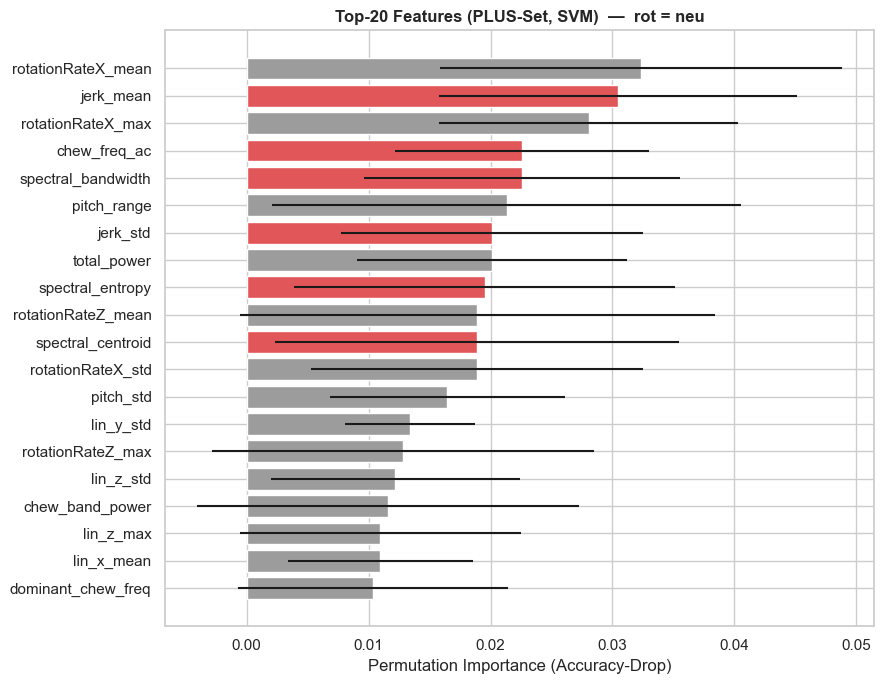

6 der Top-20 Features sind neue Dynamik-Features.


In [8]:
from sklearn.model_selection import GroupShuffleSplit

Xp = FEATURE_SETS['PLUS'].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
tr, te = next(gss.split(Xp, y_eat, grp_eat))

pipe = make_pipeline(MODELS['SVM']['clf'](), scale=True)
pipe.fit(Xp[tr], y_eat[tr])
pi = permutation_importance(pipe, Xp[te], y_eat[te], n_repeats=20,
                            random_state=42, scoring='accuracy')

feat_names = list(FEATURE_SETS['PLUS'].columns)
order = np.argsort(pi.importances_mean)[::-1][:20]
plt.figure(figsize=(9, 7))
cols = ['#e15759' if feat_names[i] in NEW_FEATURES else '#9c9c9c' for i in order]
plt.barh([feat_names[i] for i in order][::-1],
         pi.importances_mean[order][::-1],
         xerr=pi.importances_std[order][::-1], color=cols[::-1], edgecolor='white')
plt.xlabel('Permutation Importance (Accuracy-Drop)')
plt.title('Top-20 Features (PLUS-Set, SVM)  —  rot = neu', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/images/nb09_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

n_new_top = sum(1 for i in order if feat_names[i] in NEW_FEATURES)
print(f'{n_new_top} der Top-20 Features sind neue Dynamik-Features.')

---
## 9. Visualisierung

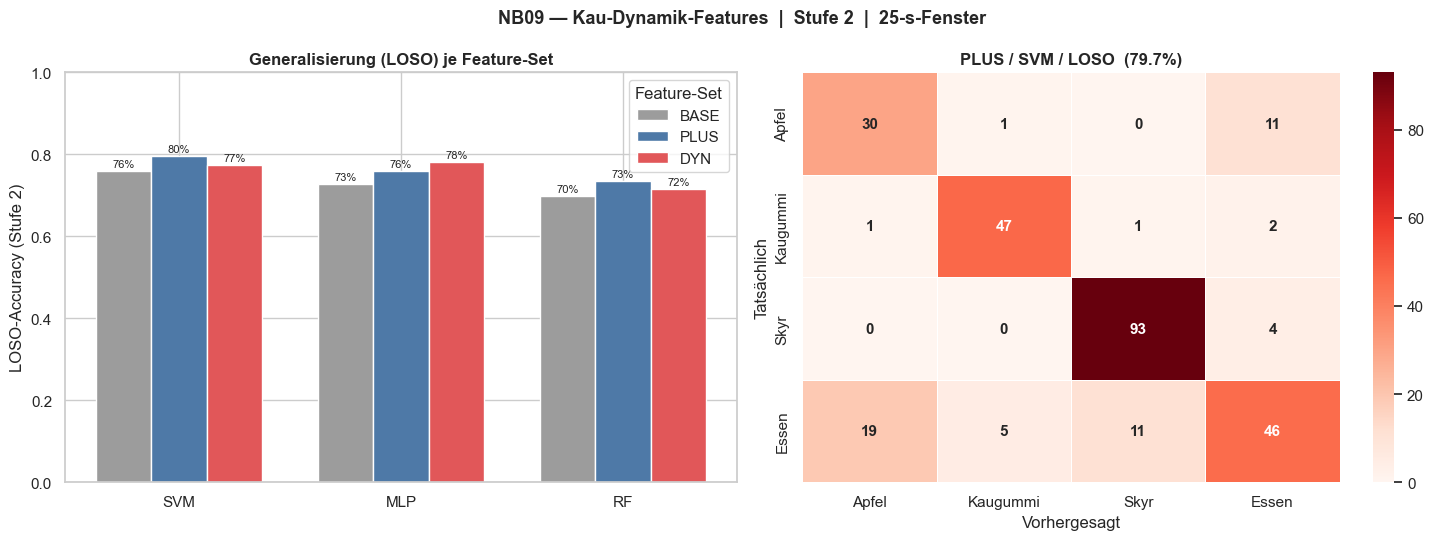

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Links: gruppiertes Balkendiagramm LOO vs LOSO je Set/Modell
ax = axes[0]
sets   = ['BASE', 'PLUS', 'DYN']
x      = np.arange(len(MODELS))
w      = 0.25
for i, set_name in enumerate(sets):
    loso_vals = [results[(set_name, m, 'LOSO')]['acc'] for m in MODELS]
    bars = ax.bar(x + (i - 1) * w, loso_vals, w, label=set_name,
                  color=SET_COLORS[set_name], edgecolor='white')
    for b, v in zip(bars, loso_vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.0%}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(list(MODELS.keys()))
ax.set_ylabel('LOSO-Accuracy (Stufe 2)'); ax.set_ylim(0, 1.0)
ax.set_title('Generalisierung (LOSO) je Feature-Set', fontweight='bold')
ax.legend(title='Feature-Set')

# Rechts: Confusion Matrix bestes PLUS-LOSO-Modell
best_m = max(MODELS, key=lambda m: results[('PLUS', m, 'LOSO')]['acc'])
r = results[('PLUS', best_m, 'LOSO')]
cm = confusion_matrix(r['yt'], r['yp'], labels=CLASSES_FINE)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=CLASSES_FINE,
            yticklabels=CLASSES_FINE, ax=axes[1], linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, vmin=0)
axes[1].set_title(f'PLUS / {best_m} / LOSO  ({r["acc"]:.1%})', fontweight='bold')
axes[1].set_xlabel('Vorhergesagt'); axes[1].set_ylabel('Tatsächlich')

plt.suptitle('NB09 — Kau-Dynamik-Features  |  Stufe 2  |  25-s-Fenster',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/images/nb09_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Fazit (nach dem Lauf ausfüllen)

- **Helfen die neuen Features dem LOO?** → erwartbar klein (LOO ist schon ~93 %).
- **Helfen sie dem LOSO?** → das ist der eigentliche Test. Positives Δ LOSO = bessere
  Generalisierung auf neue Sessions.
- **Permutation Importance:** Welche Dynamik-Features landen oben? (Erwartung:
  `spectral_entropy`, `high_freq_power`, `ac_peak_height` für Apfel/Kaugummi.)
- **Nächster Schritt:** Falls PLUS das LOSO verbessert → Feature-Funktion in
  `classifier_app.py` übernehmen. Falls nicht → bestätigt NB07: das Limit ist die
  **Datenvielfalt** (mehr Personen/Sessions), nicht die Feature-Repräsentation.